In [2]:
from google.colab import drive
drive.mount('/content/drive')
# df = pd.read_csv(r"/content/drive/MyDrive/surge/Hourly_Data_220kV.csv")


Mounted at /content/drive


In [11]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed, Attention, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

# --- Define Your Candidates ---
# (Assume 'df' is your fully merged dataframe from earlier, before dropping any columns)
target_col = 'Total Load (MW)'

# These are the features you want to test one by one alongside Load
candidate_features = [
    'temperature_2m',
    'relative_humidity_2m',
    'cloud_cover',
    'wind_speed_10m',
    'precipitation',
    'hour_sin',
    'dow_sin'
]

results = []
look_back, horizon = 168, 24

def create_sequences(X_data, y_data, look_back, horizon):
    X, y = [], []
    for i in range(look_back, len(X_data) - horizon + 1):
        X.append(X_data[i - look_back : i])
        y.append(y_data[i : i + horizon])
    return np.array(X), np.array(y)

# Loop through every candidate feature
for feature in candidate_features:
    print(f"\n" + "="*50)
    print(f"🧪 TESTING: {target_col} + {feature}")
    print("="*50)

    # 1. Prep Data for this specific pair
    current_cols = [target_col, feature]
    temp_df = df[current_cols].dropna()

    train_df = temp_df[temp_df.index < '2025-05-27']
    val_df   = temp_df[(temp_df.index >= '2025-05-28') & (temp_df.index < '2025-08-09')]
    test_df  = temp_df[temp_df.index >= '2025-08-14']

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    train_scaled = scaler_X.fit_transform(train_df[current_cols])
    val_scaled   = scaler_X.transform(val_df[current_cols])
    test_scaled  = scaler_X.transform(test_df[current_cols])

    train_y = scaler_y.fit_transform(train_df[[target_col]])
    val_y   = scaler_y.transform(val_df[[target_col]])
    test_y  = scaler_y.transform(test_df[[target_col]])

    X_train, y_train = create_sequences(train_scaled, train_y, look_back, horizon)
    X_val, y_val     = create_sequences(val_scaled, val_y, look_back, horizon)
    X_test, y_test   = create_sequences(test_scaled, test_y, look_back, horizon)

    # 2. Build the Model (Fresh weights every time)
    K.clear_session() # Clears Keras memory so models don't bleed into each other

    encoder_inputs = Input(shape=(look_back, 2)) # 2 features: Load + Candidate
    encoder_out, state_h, state_c = LSTM(64, activation='tanh', return_sequences=True, return_state=True)(encoder_inputs)
    decoder_inputs = RepeatVector(horizon)(state_h)
    decoder_out = LSTM(64, activation='tanh', return_sequences=True)(decoder_inputs, initial_state=[state_h, state_c])
    attention_out = Attention()([decoder_out, encoder_out])
    decoder_combined = Concatenate(axis=-1)([decoder_out, attention_out])
    output = TimeDistributed(Dense(1))(decoder_combined)

    model = Model(encoder_inputs, output)
    model.compile(optimizer='adam', loss='mse')

    # 3. Train (Fast mode: Max 8 epochs, stops early if it gets worse)
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    start_time = time.time()
    model.fit(
        X_train, y_train,
        epochs=8,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0 # Set to 1 if you want to watch it train
    )

    # 4. Evaluate
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1, horizon)
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, horizon)

    r2 = r2_score(y_true[:, 0], y_pred[:, 0])
    rmse = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))

    print(f"R²: {r2:.4f} | RMSE: {rmse:.2f} MW")

    # Save results
    results.append({
        'Feature_Added': feature,
        'R2_Score': r2,
        'RMSE': rmse
    })

# --- Print the Final Leaderboard ---
print("\n" + "*"*50)
print("🏆 FINAL FEATURE LEADERBOARD 🏆")
print("*"*50)
leaderboard = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False).reset_index(drop=True)
print(leaderboard.to_markdown())


🧪 TESTING: Total Load (MW) + temperature_2m
R²: 0.9017 | RMSE: 10.36 MW

🧪 TESTING: Total Load (MW) + relative_humidity_2m
R²: 0.8995 | RMSE: 10.47 MW

🧪 TESTING: Total Load (MW) + cloud_cover
R²: 0.8330 | RMSE: 13.50 MW

🧪 TESTING: Total Load (MW) + wind_speed_10m
R²: 0.8479 | RMSE: 12.88 MW

🧪 TESTING: Total Load (MW) + precipitation
R²: 0.8884 | RMSE: 11.03 MW

🧪 TESTING: Total Load (MW) + hour_sin
R²: 0.9204 | RMSE: 9.32 MW

🧪 TESTING: Total Load (MW) + dow_sin
R²: 0.8938 | RMSE: 10.77 MW

**************************************************
🏆 FINAL FEATURE LEADERBOARD 🏆
**************************************************
|    | Feature_Added        |   R2_Score |     RMSE |
|---:|:---------------------|-----------:|---------:|
|  0 | hour_sin             |   0.920413 |  9.31771 |
|  1 | temperature_2m       |   0.901664 | 10.3572  |
|  2 | relative_humidity_2m |   0.899492 | 10.471   |
|  3 | dow_sin              |   0.893754 | 10.7658  |
|  4 | precipitation        |   0.888374 | 1

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed, Attention, Concatenate


df = pd.read_csv(r"/content/drive/MyDrive/surge/Hourly_Data_220kV.csv")

df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df.dropna(subset=['Datetime'])
df = df.drop_duplicates(subset=['Datetime'], keep='first')
df.set_index('Datetime', inplace=True)
df['Total Load (MW)'] = df['Total Load (MW)'].astype(str).str.replace(',', '')
df['Total Load (MW)'] = pd.to_numeric(df['Total Load (MW)'], errors='coerce')
df['Total Load (MW)'] = df['Total Load (MW)'].replace(0, np.nan)
df = df.asfreq('1H')
df['Total Load (MW)'] = df['Total Load (MW)'].interpolate(method='linear').ffill().bfill()

train_df = df[df.index < '2025-05-27'].copy()
val_df = df[(df.index >= '2025-05-28') & (df.index < '2025-08-09')].copy()
test_df = df[df.index >= '2025-08-14'].copy()

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[['Total Load (MW)']])
val_scaled = scaler.transform(val_df[['Total Load (MW)']])
test_scaled = scaler.transform(test_df[['Total Load (MW)']])

look_back = 168
forecast_horizon = 24

def create_sequences(data, look_back, horizon):
    X, y = [], []
    for i in range(look_back, len(data) - horizon + 1):
        X.append(data[i - look_back : i])
        y.append(data[i : i + horizon])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, look_back, forecast_horizon)
X_val, y_val = create_sequences(val_scaled, look_back, forecast_horizon)
X_test, y_test = create_sequences(test_scaled, look_back, forecast_horizon)

encoder_inputs = Input(shape=(look_back, 1))
encoder_out, state_h, state_c = LSTM(64, activation='tanh', return_sequences=True, return_state=True)(encoder_inputs)

decoder_inputs = RepeatVector(forecast_horizon)(state_h)
decoder_out = LSTM(64, activation='tanh', return_sequences=True)(decoder_inputs, initial_state=[state_h, state_c])

attention_out = Attention()([decoder_out, encoder_out])
decoder_combined_context = Concatenate(axis=-1)([decoder_out, attention_out])
output = TimeDistributed(Dense(1))(decoder_combined_context)

model_attn = Model(inputs=encoder_inputs, outputs=output)
model_attn.compile(optimizer='adam', loss='mse')

model_attn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

y_pred_scaled = model_attn.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1, forecast_horizon)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, forecast_horizon)

mae = mean_absolute_error(y_test_unscaled[:, 0], y_pred[:, 0])
rmse = np.sqrt(mean_squared_error(y_test_unscaled[:, 0], y_pred[:, 0]))
r2 = r2_score(y_test_unscaled[:, 0], y_pred[:, 0])

print("\n--- ATTENTION SEQ2SEQ PERFORMANCE ---")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Epoch 1/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - loss: 0.3448 - val_loss: 0.1808
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2211 - val_loss: 0.1557
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.1658 - val_loss: 0.1498
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1479 - val_loss: 0.1209
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1404 - val_loss: 0.1109
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.1656 - val_loss: 0.1045
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.1506 - val_loss: 0.1192
Epoch 8/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.1284 - val_loss: 0.1091
Epoch 9/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1244 - val_loss: 0.0969
Epoch 10/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1222 - val_loss: 0.0914
Epoch 11/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.1179 - val_loss: 0.0930
Epoch 12/20
402/402 ━━━━━━━━━━━━━━━━━━━━


             GRID MODEL EVALUATION REPORT
Overall MAE         : 7.02 MW
Overall RMSE        : 10.05 MW
Overall R² Score    : 0.9074
Overall MAPE        : 13.84%
--------------------------------------------------
90th Percentile Peak Cutoff : 110.92 MW
Peak Demand Hour MAE       : 12.64 MW
Peak Demand Hour Accuracy  : 90.43%



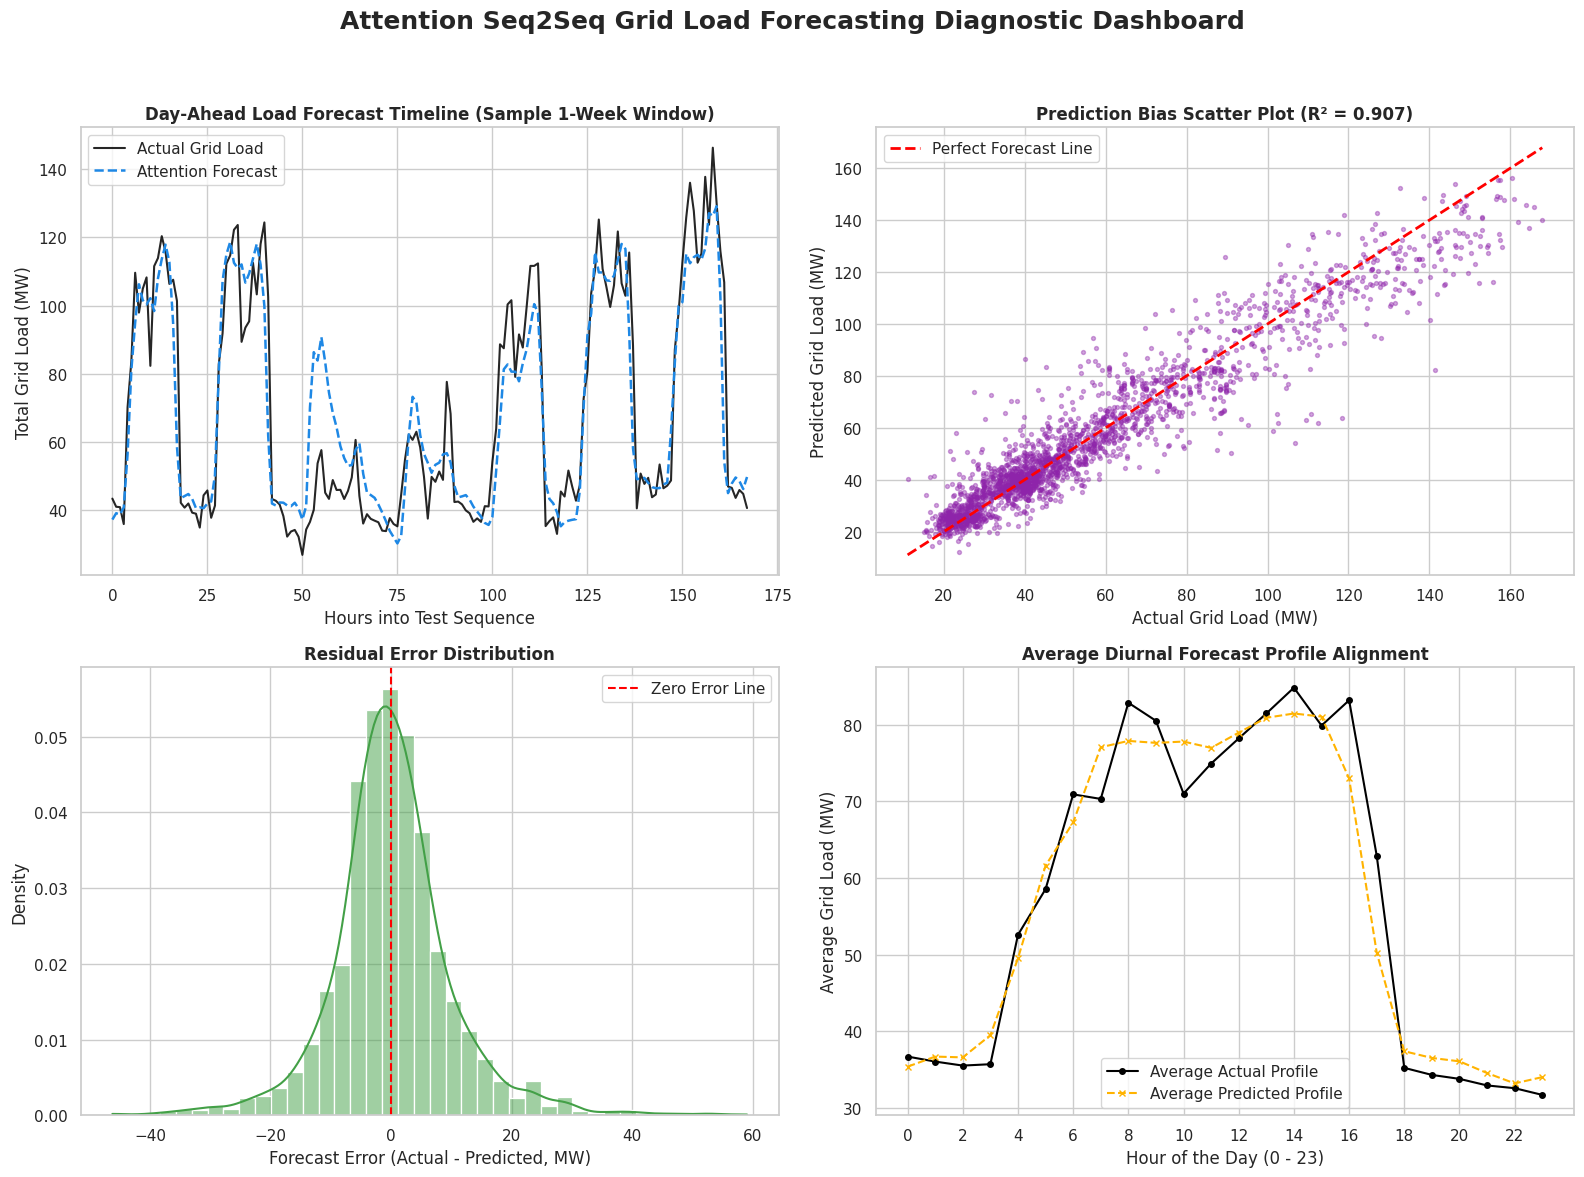

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional, clean theme for the diagnostics dashboard
sns.set_theme(style="whitegrid")

# We isolate the first-step prediction (t+1) to evaluate the next-hour forecast accuracy
test_actuals = y_test_unscaled[:, 0]
test_preds = y_pred[:, 0]

# Calculate standard regression metrics
mae_val = mean_absolute_error(test_actuals, test_preds)
rmse_val = np.sqrt(mean_squared_error(test_actuals, test_preds))
r2_val = r2_score(test_actuals, test_preds)
mape_val = np.mean(np.abs((test_actuals - test_preds) / test_actuals)) * 100

# Peak demand accuracy is critical for grid stability and dispatch operations
peak_threshold = np.percentile(test_actuals, 90)
peak_indices = np.where(test_actuals >= peak_threshold)[0]
peak_mae = mean_absolute_error(test_actuals[peak_indices], test_preds[peak_indices])
peak_accuracy = (1 - (peak_mae / np.mean(test_actuals[peak_indices]))) * 100

print("\n" + "="*50)
print("             GRID MODEL EVALUATION REPORT")
print("="*50)
print(f"Overall MAE         : {mae_val:.2f} MW")
print(f"Overall RMSE        : {rmse_val:.2f} MW")
print(f"Overall R² Score    : {r2_val:.4f}")
print(f"Overall MAPE        : {mape_val:.2f}%")
print("-"*50)
print(f"90th Percentile Peak Cutoff : {peak_threshold:.2f} MW")
print(f"Peak Demand Hour MAE       : {peak_mae:.2f} MW")
print(f"Peak Demand Hour Accuracy  : {peak_accuracy:.2f}%")
print("="*50 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Attention Seq2Seq Grid Load Forecasting Diagnostic Dashboard', fontsize=18, fontweight='bold')

# Plot 1: Day-Ahead Load Forecast Timeline (1-Week Window)
zoom_idx = 168  # 1 week of hourly data
axes[0, 0].plot(test_actuals[:zoom_idx], label='Actual Grid Load', color='black', alpha=0.85, linewidth=1.5)
axes[0, 0].plot(test_preds[:zoom_idx], label='Attention Forecast', color='#1e88e5', linestyle='--', linewidth=1.8)
axes[0, 0].set_title('Day-Ahead Load Forecast Timeline (Sample 1-Week Window)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hours into Test Sequence')
axes[0, 0].set_ylabel('Total Grid Load (MW)')
axes[0, 0].legend()

# Plot 2: Prediction Bias Scatter Plot
max_val = max(np.max(test_actuals), np.max(test_preds))
min_val = min(np.min(test_actuals), np.min(test_preds))
axes[0, 1].scatter(test_actuals, test_preds, color='#8e24aa', alpha=0.4, s=8)
axes[0, 1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Forecast Line')
axes[0, 1].set_title(f'Prediction Bias Scatter Plot (R² = {r2_val:.3f})', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Actual Grid Load (MW)')
axes[0, 1].set_ylabel('Predicted Grid Load (MW)')
axes[0, 1].legend()

# Plot 3: Residual Error Distribution
residuals = test_actuals - test_preds
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='#43a047', bins=40, stat="density")
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')
axes[1, 0].set_title('Residual Error Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Forecast Error (Actual - Predicted, MW)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# Plot 4: Diurnal (Daily Hourly) Forecast Profile Alignment
test_dates = test_df.index[look_back : look_back + len(test_actuals)]
diurnal_df = pd.DataFrame({
    'Hour': test_dates.hour,
    'Actual': test_actuals,
    'Predicted': test_preds
})
avg_diurnal = diurnal_df.groupby('Hour').mean()

axes[1, 1].plot(avg_diurnal.index, avg_diurnal['Actual'], label='Average Actual Profile', color='black', marker='o', markersize=4)
axes[1, 1].plot(avg_diurnal.index, avg_diurnal['Predicted'], label='Average Predicted Profile', color='#ffb300', linestyle='--', marker='x', markersize=4)
axes[1, 1].set_title('Average Diurnal Forecast Profile Alignment', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Hour of the Day (0 - 23)')
axes[1, 1].set_ylabel('Average Grid Load (MW)')
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('seq2seq_attention_diagnostics.png', dpi=300)
plt.show()